# U-Net Training - Implementação Corrigida

Baseado em: **U-Net: Convolutional Networks for Biomedical Image Segmentation** (Ronneberger et al., 2015)

Dataset: **BCCD - Blood Cells Classification Dataset**

## Modificações do Notebook Original
✅ Convoluções VALID (conforme artigo)
✅ Overlapping tiles para imagens variáveis
✅ Mapa de pesos corrigido
✅ Learning rate scheduling
✅ Batch size > 1 (melhor convergência)
✅ Checkpoints automáticos

In [12]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from pathlib import Path
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from scipy.ndimage import distance_transform_edt
from skimage.measure import label
import matplotlib.pyplot as plt
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Usando dispositivo: {device}')

Usando dispositivo: cuda


In [13]:
os.chdir("/home/aluno/Documentos/projects/trabalho-final-visComp")

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jeetblahiri/bccd-dataset-with-mask")

print("Path to dataset files:", path)

In [ ]:
import shutil

destino = "/home/aluno/Documentos/projects/trabalho-final-visComp" 

# 3. Mover os arquivos
try:
    # Se você quiser mover a pasta inteira baixada para dentro do diretório atual:
    shutil.move(path, destino)
    print(f"Dataset movido com sucesso para: {os.path.abspath(destino)}")
except Exception as e:
    print(f"Ocorreu um erro ao mover ou os arquivos já existem no destino: {e}")

## Passo 1: Dataset com Overlapping Tiles

In [34]:
class UNetTileDataset(Dataset):
    """Dataset que extrai tiles aleatórios de imagens."""
    
    def __init__(self, img_dir, mask_dir, peso_dir, tile_size=572, samples_per_image=4):
        self.img_dir = Path(img_dir)
        self.mask_dir = Path(mask_dir)
        self.peso_dir = Path(peso_dir)
        self.tile_size = tile_size
        self.samples_per_image = samples_per_image
        
        self.img_files = sorted([f.name for f in self.img_dir.glob('*.*') 
                                 if f.suffix.lower() in ('.png', '.jpg', '.jpeg', '.tif')])
        
        print(f'✓ Dataset carregado: {len(self.img_files)} imagens')
    
    def __len__(self):
        return len(self.img_files) * self.samples_per_image
    

    def __getitem__(self, idx):
        img_idx = idx // self.samples_per_image
        # Garante que img_file seja tratado como um objeto Path para facilitar manipulações
        img_file = Path(self.img_files[img_idx])
        
        # 1. Imagem original (carrega com a extensão original .jpg ou .png)
        img = Image.open(self.img_dir / img_file).convert('L')
        
        # 2. Máscara: Troca a extensão original para .png, não importa qual seja
        mask_file = img_file.with_suffix('.png')
        mask = Image.open(self.mask_dir / mask_file).convert('L')
        
        # 3. Peso: Troca a extensão original para .npy
        peso_file = img_file.with_suffix('.npy')
        peso = np.load(self.peso_dir / peso_file)
        
        img_np = np.array(img, dtype=np.float32) / 255.0
        mask_np = np.array(mask, dtype=np.uint8) > 128
        
        h, w = img_np.shape
        
        # Extrai tile aleatório
        if h >= self.tile_size and w >= self.tile_size:
            y = np.random.randint(0, h - self.tile_size + 1)
            x = np.random.randint(0, w - self.tile_size + 1)
        else:
            # Padding se imagem é pequena
            y, x = 0, 0
            pad_h = max(0, self.tile_size - h)
            pad_w = max(0, self.tile_size - w)
            
            img_np = np.pad(img_np, ((pad_h // 2, pad_h - pad_h // 2), 
                                    (pad_w // 2, pad_w - pad_w // 2)), 
                        mode='reflect')
            mask_np = np.pad(mask_np, ((pad_h // 2, pad_h - pad_h // 2), 
                                    (pad_w // 2, pad_w - pad_w // 2)), 
                            mode='constant', constant_values=0)
            peso = np.pad(peso, ((pad_h // 2, pad_h - pad_h // 2), 
                                (pad_w // 2, pad_w - pad_w // 2)), 
                        mode='constant', constant_values=1.0)
        
        tile_img = img_np[y:y + self.tile_size, x:x + self.tile_size]
        tile_mask = mask_np[y:y + self.tile_size, x:x + self.tile_size]
        tile_peso = peso[y:y + self.tile_size, x:x + self.tile_size]
        
        return (
            torch.from_numpy(tile_img).unsqueeze(0).float(),  # [1, H, W]
            torch.from_numpy(tile_mask.astype(np.int64)),     # [H, W]
            torch.from_numpy(tile_peso).float()               # [H, W]
        )

## Passo 2: Mapa de Pesos Correto

In [17]:
def calcular_mapa_pesos_unet(mascara_binaria, w0=10, sigma=5):
    """Calcula mapa de pesos conforme artigo original."""
    
    mascara_instancias, num_instancias = label(mascara_binaria, return_num=True)
    
    if num_instancias < 2:
        return np.ones_like(mascara_binaria, dtype=np.float32)
    
    distancias = np.zeros((num_instancias, *mascara_binaria.shape), dtype=np.float32)
    
    for i in range(1, num_instancias + 1):
        instancia_mask = (mascara_instancias == i).astype(np.uint8)
        distancias[i - 1] = distance_transform_edt(1 - instancia_mask)
    
    distancias_ordenadas = np.sort(distancias, axis=0)
    d1 = distancias_ordenadas[0]
    d2 = distancias_ordenadas[1]
    
    fundo = (mascara_binaria == 0)
    peso_fronteira = w0 * np.exp(-((d1 + d2)**2) / (2 * sigma**2))
    
    mapa_pesos = np.ones_like(mascara_binaria, dtype=np.float32)
    mapa_pesos[fundo] += peso_fronteira[fundo]
    
    return mapa_pesos

## Passo 3: Arquitetura U-Net com VALID Convolutions

In [18]:
class DoubleConv(nn.Module):
    """Dupla convolução com VALID (sem padding)."""
    
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=0),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=0),
            nn.ReLU(inplace=True)
        )
    
    def forward(self, x):
        return self.conv(x)

In [19]:
class UNet(nn.Module):
    """U-Net original com VALID convolutions."""
    
    def __init__(self, in_channels=1, out_channels=2):
        super().__init__()
        
        # ENCODER
        self.down1 = DoubleConv(in_channels, 64)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.down2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.down3 = DoubleConv(128, 256)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.down4 = DoubleConv(256, 512)
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # BOTTLENECK
        self.bottleneck = DoubleConv(512, 1024)
        
        # DECODER
        self.upconv4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.up4 = DoubleConv(1024, 512)
        
        self.upconv3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.up3 = DoubleConv(512, 256)
        
        self.upconv2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.up2 = DoubleConv(256, 128)
        
        self.upconv1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.up1 = DoubleConv(128, 64)
        
        # OUTPUT
        self.out_conv = nn.Conv2d(64, out_channels, kernel_size=1)
        
        self._init_weights()
    
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
                nn.init.kaiming_normal_(m.weight, mode='fan_in', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
    
    def forward(self, x):
        # ENCODER
        x1 = self.down1(x)
        p1 = self.pool1(x1)
        
        x2 = self.down2(p1)
        p2 = self.pool2(x2)
        
        x3 = self.down3(p2)
        p3 = self.pool3(x3)
        
        x4 = self.down4(p3)
        p4 = self.pool4(x4)
        
        # BOTTLENECK
        bn = self.bottleneck(p4)
        
        # DECODER
        up4 = self.upconv4(bn)
        x4_crop = self._crop_and_concat(x4, up4)
        d4 = self.up4(x4_crop)
        
        up3 = self.upconv3(d4)
        x3_crop = self._crop_and_concat(x3, up3)
        d3 = self.up3(x3_crop)
        
        up2 = self.upconv2(d3)
        x2_crop = self._crop_and_concat(x2, up2)
        d2 = self.up2(x2_crop)
        
        up1 = self.upconv1(d2)
        x1_crop = self._crop_and_concat(x1, up1)
        d1 = self.up1(x1_crop)
        
        out = self.out_conv(d1)
        
        return out
    
    def _crop_and_concat(self, x_large, x_small):
        """Crop e concatena skip connections."""
        _, _, h_large, w_large = x_large.shape
        _, _, h_small, w_small = x_small.shape
        
        h_crop = (h_large - h_small) // 2
        w_crop = (w_large - w_small) // 2
        
        x_large_cropped = x_large[
            :, :,
            h_crop:h_crop + h_small,
            w_crop:w_crop + w_small
        ]
        
        return torch.cat([x_large_cropped, x_small], dim=1)

## Passo 4: Testar Arquitetura

In [20]:
print('[TESTE] Validando arquitetura U-Net')
x = torch.randn((1, 1, 572, 572)).to(device)
model = UNet(in_channels=1, out_channels=2).to(device)

with torch.no_grad():
    y = model(x)

print(f'Entrada:  {x.shape} (esperado: [1, 1, 572, 572])')
print(f'Saída:    {y.shape} (esperado: [1, 2, 388, 388])')

total_params = sum(p.numel() for p in model.parameters())
print(f'Parâmetros totais: {total_params:,}')

[TESTE] Validando arquitetura U-Net
Entrada:  torch.Size([1, 1, 572, 572]) (esperado: [1, 1, 572, 572])
Saída:    torch.Size([1, 2, 388, 388]) (esperado: [1, 2, 388, 388])
Parâmetros totais: 31,030,658


## Passo 5: Treinamento

In [ ]:
import glob
import cv2

# Calcular mapa de pesos para uma máscara de teste
def processar_diretorio_de_mascaras(diretorio_entrada, diretorio_saida, w0=10, sigma=5):
    """
    Lê todas as máscaras de um diretório, calcula o mapa de pesos
    e salva o resultado em um diretório de saída.
    """
    # Cria o diretório de saída caso ele não exista
    os.makedirs(diretorio_saida, exist_ok=True)
    
    # Lista de extensões comuns de imagem para buscar no diretório
    extensoes = ('*.png', '*.jpg', '*.jpeg', '*.tif', '*.tiff')
    arquivos_mascaras = []
    
    for ext in extensoes:
        arquivos_mascaras.extend(glob.glob(os.path.join(diretorio_entrada, ext)))
        
    if not arquivos_mascaras:
        print(f"Nenhuma imagem encontrada em: {diretorio_entrada}")
        return

    print(f"Encontradas {len(arquivos_mascaras)} máscaras para processar.")

    for caminho_arquivo in arquivos_mascaras:
        # Extrai o nome do arquivo e a extensão
        nome_arquivo = os.path.basename(caminho_arquivo)
        nome_sem_ext = os.path.splitext(nome_arquivo)[0]
        
        # 1. Carrega a imagem em escala de cinza (grayscale)
        mascara = cv2.imread(caminho_arquivo, cv2.IMREAD_GRAYSCALE)
        
        if mascara is None:
            print(f"Erro ao ler o arquivo: {nome_arquivo}. Pulando...")
            continue
            
        # 2. Garante que a máscara seja binária (0 ou 1)
        # Imagens comuns vêm no intervalo [0, 255]. A função precisa de [0, 1] ou Booleano.
        mascara_binaria = (mascara > 127).astype(np.uint8)
        
        # 3. Executa a sua função
        mapa_pesos = calcular_mapa_pesos_unet(mascara_binaria, w0=w0, sigma=sigma)
        
        # 4. Salva o mapa de pesos como arquivo .npy para preservar a precisão float32
        caminho_salvamento = os.path.join(diretorio_saida, f"{nome_sem_ext}.npy")
        np.save(caminho_salvamento, mapa_pesos)
        
        print(f"Sucesso: {nome_arquivo} -> Processado e salvo.")

# --- EXEMPLO DE USO ---
pasta_das_mascaras = "BCCD Dataset with mask/train/mask"
pasta_dos_pesos = "BCCD Dataset with mask/train/peso"
processar_diretorio_de_mascaras(pasta_das_mascaras, pasta_dos_pesos)

Encontradas 1169 máscaras para processar.
Sucesso: acdc6e12-73d9-44ba-be8c-2a56aaffef4f.png -> Processado e salvo.
Sucesso: da2197c7-7911-4be6-8bb9-164f47fd270a.png -> Processado e salvo.
Sucesso: b600b38d-225b-46a5-b6f8-b607430f6a10.png -> Processado e salvo.
Sucesso: 5077f87d-a19f-494c-b911-14ccb03bd230.png -> Processado e salvo.
Sucesso: bb2042c5-35e1-43cc-8171-7de81b764361.png -> Processado e salvo.
Sucesso: 6fd30823-3b77-40c9-ba5d-e1eda9660674.png -> Processado e salvo.
Sucesso: 33068c1a-48f7-470b-8e49-e2f0888042e9.png -> Processado e salvo.
Sucesso: 0fcd1ebe-ee4a-40a0-b787-29cee18bfa1b.png -> Processado e salvo.
Sucesso: 49c4dbd3-6269-4d4c-9648-a2146c57bab1.png -> Processado e salvo.
Sucesso: b4e5e08d-6427-46f3-aca8-a4df165a151d.png -> Processado e salvo.
Sucesso: 04d21589-b777-43c2-86b5-038cbf8c3a4e.png -> Processado e salvo.
Sucesso: 169d541c-daed-468e-8b41-0f1abccdf319.png -> Processado e salvo.
Sucesso: ca734448-0d52-42fa-b41c-17b2939e58ae.png -> Processado e salvo.
Sucesso: 

In [32]:
def remover_weight_dos_nomes():
    # Obtém o diretório onde o script está sendo executado
    path = "BCCD Dataset with mask/train/peso"
    
    print(f"Examinando arquivos em: {path}\n")
    contador = 0

    # Lista todos os arquivos da pasta
    for nome_arquivo in os.listdir(path):
        # Ignora se for uma pasta
        if os.path.isdir(os.path.join(path, nome_arquivo)):
            continue
            
        # Separa o nome do arquivo da sua extensão (ex: .txt, .json, .png)
        nome_base, extensao = os.path.splitext(nome_arquivo)
        
        # Verifica se o nome base termina com '_weight'
        if nome_base.endswith('_weight'):
            # Remove o '_weight' do final do nome base
            novo_nome_base = nome_base[:-7] # '_weight' tem 7 caracteres
            novo_nome = novo_nome_base + extensao
            
            # Caminhos completos para o renomeio seguro
            caminho_antigo = os.path.join(path, nome_arquivo)
            caminho_novo = os.path.join(path, novo_nome)
            
            # Renomeia o arquivo
            os.rename(caminho_antigo, caminho_novo)
            print(f"Renomeado: {nome_arquivo}  -->  {novo_nome}")
            contador += 1

    print(f"\nProcesso concluído! {contador} arquivos foram renomeados.")

if __name__ == "__main__":
    remover_weight_dos_nomes()

Examinando arquivos em: BCCD Dataset with mask/train/peso


Processo concluído! 0 arquivos foram renomeados.


In [40]:
# CRIE SEU DATASET AQUI
# PRIMEIRO: Certifique-se de que tem pesos pré-calculados em BCCD/train/peso/
# Para calcular: use calcular_mapa_pesos_unet() para cada máscara

dataset_train = UNetTileDataset(
    'BCCD Dataset with mask/train/original',
    'BCCD Dataset with mask/train/mask',
    'BCCD Dataset with mask/train/peso',
    tile_size=572,
    samples_per_image=4
)

dataloader_train = DataLoader(
    dataset_train,
    batch_size=8,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

# Instancia modelo
model = UNet(in_channels=1, out_channels=2).to(device)

# Otimizador
optimizer = optim.SGD(
    model.parameters(),
    lr=0.001,
    momentum=0.99,
    weight_decay=0.0005,
    nesterov=True
)

# Scheduler
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

# Loss com reduction='none' para aplicar pesos
criterio = nn.CrossEntropyLoss(reduction='none')

# Histórico
history = {'train_loss': [], 'learning_rates': []}

✓ Dataset carregado: 1168 imagens


In [41]:
# LOOP DE TREINAMENTO
num_epochs = 50

for epoch in range(num_epochs):
    model.train()
    loss_acumulada = 0.0
    
    with tqdm(total=len(dataloader_train), desc=f'Época {epoch+1}/{num_epochs}') as pbar:
        for batch_img, batch_mask, batch_peso in dataloader_train:
            # Move para GPU
            batch_img = batch_img.to(device)      # [B, 1, 572, 572]
            batch_mask = batch_mask.to(device)    # [B, 572, 572]
            batch_peso = batch_peso.to(device)    # [B, 572, 572]
            
            # Forward
            predicoes = model(batch_img)          # [B, 2, 388, 388]
            
            # ⚠️ CRUCIAL: Crop de mask/peso para 388×388
            target_h, target_w = predicoes.shape[2:]
            h_crop = (batch_mask.shape[1] - target_h) // 2
            w_crop = (batch_mask.shape[2] - target_w) // 2
            
            batch_mask_crop = batch_mask[
                :,
                h_crop:h_crop + target_h,
                w_crop:w_crop + target_w
            ]
            batch_peso_crop = batch_peso[
                :,
                h_crop:h_crop + target_h,
                w_crop:w_crop + target_w
            ]
            
            # Loss
            loss_pixel = criterio(predicoes, batch_mask_crop)
            loss_ponderada = loss_pixel * batch_peso_crop
            loss = torch.mean(loss_ponderada)
            
            # Backward
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            loss_acumulada += loss.item()
            pbar.update(1)
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    # Média da época
    loss_media = loss_acumulada / len(dataloader_train)
    history['train_loss'].append(loss_media)
    
    # Scheduler
    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]
    history['learning_rates'].append(current_lr)
    
    print(f'✓ Época {epoch+1} - Loss: {loss_media:.4f} - LR: {current_lr:.6f}')
    
    # Checkpoint
    if (epoch + 1) % 5 == 0:
        os.makedirs('checkpoints', exist_ok=True)
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': loss_media
        }, f'checkpoints/unet_epoch_{epoch+1}.pth')
        print(f'✓ Checkpoint salvo')

# Salva modelo final
torch.save(model.state_dict(), 'unet_final.pth')
print('\n✓ TREINAMENTO COMPLETO!')

Época 1/50: 100%|██████████| 584/584 [01:56<00:00,  5.02it/s, loss=0.1823]


✓ Época 1 - Loss: 0.2328 - LR: 0.001000


Época 2/50: 100%|██████████| 584/584 [01:56<00:00,  5.02it/s, loss=0.0967]


✓ Época 2 - Loss: 0.1293 - LR: 0.001000


Época 3/50: 100%|██████████| 584/584 [01:56<00:00,  5.01it/s, loss=0.0857]


...

✓ Época 48 - Loss: 0.0742 - LR: 0.000063


Época 49/50: 100%|██████████| 584/584 [01:56<00:00,  5.01it/s, loss=0.1164]


✓ Época 49 - Loss: 0.0739 - LR: 0.000063


Época 50/50: 100%|██████████| 584/584 [01:56<00:00,  5.01it/s, loss=0.0558]

✓ Época 50 - Loss: 0.0743 - LR: 0.000031
✓ Checkpoint salvo

✓ TREINAMENTO COMPLETO!


## Passo 6: Visualizar Treinamento

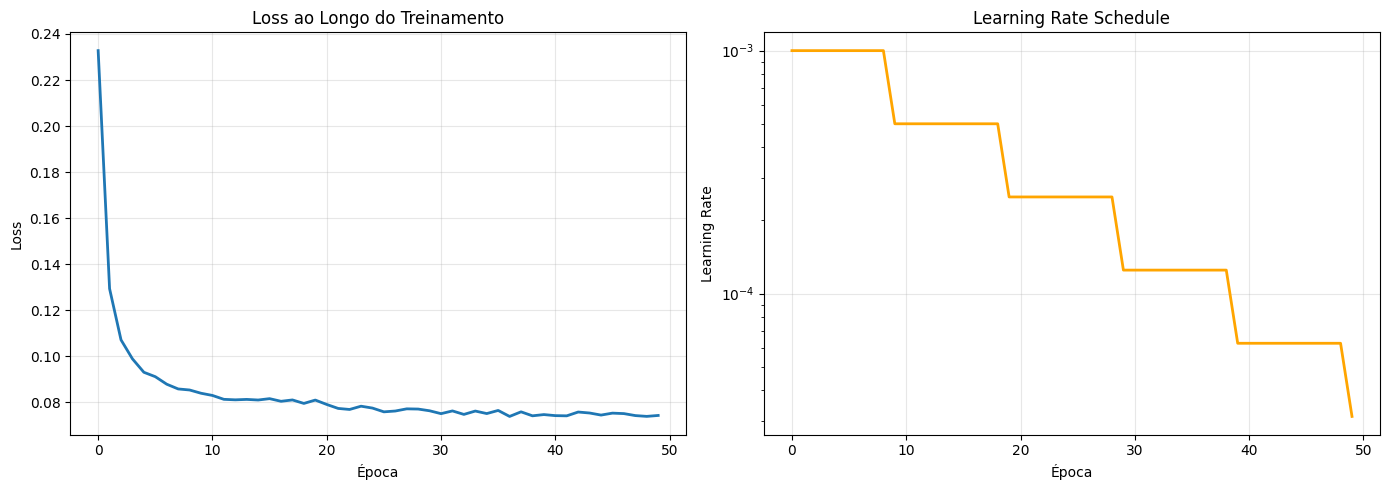

✓ Gráfico salvo: training_history.png


In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history['train_loss'], linewidth=2)
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss ao Longo do Treinamento')
axes[0].grid(True, alpha=0.3)

# Learning Rate
if history['learning_rates']:
    axes[1].plot(history['learning_rates'], linewidth=2, color='orange')
    axes[1].set_xlabel('Época')
    axes[1].set_ylabel('Learning Rate')
    axes[1].set_title('Learning Rate Schedule')
    axes[1].set_yscale('log')
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=100)
plt.show()

print('✓ Gráfico salvo: training_history.png')

Iniciando inferência em 159 imagens de teste...
\n========================================
 RESULTADOS MÉDIOS NO CONJUNTO DE TESTE 
Acurácia de Pixel : 0.7664
Mean IoU          : 0.3023
Mean Dice Score   : 0.4353
========================================\n


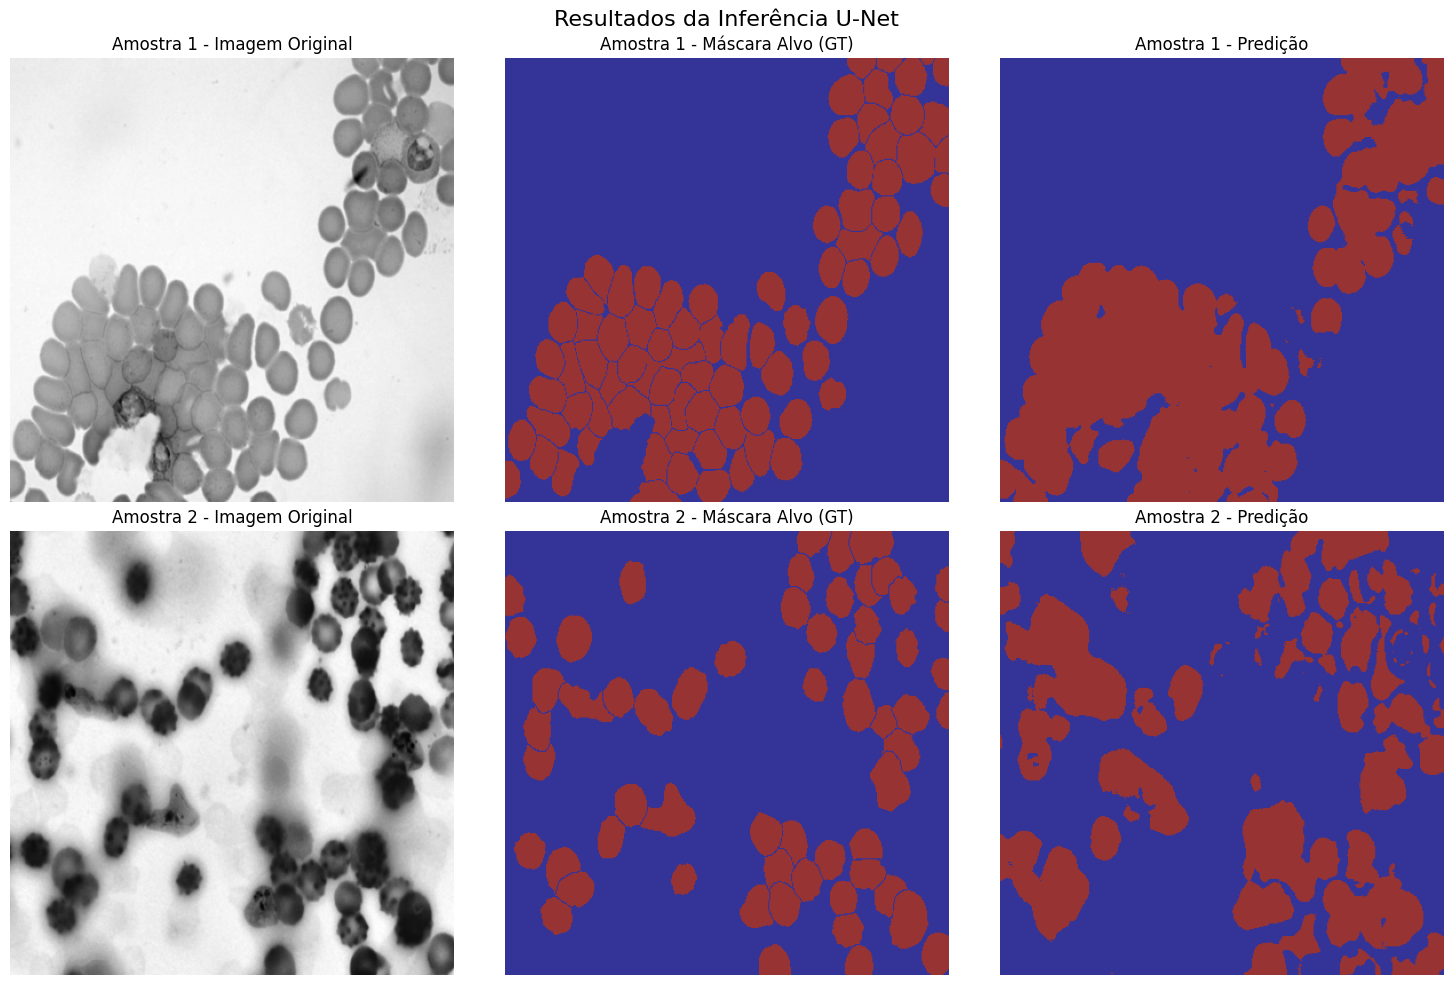

In [43]:
# ---------------------------------------------------------
# 1. DEFINIÇÕES E CARREGAMENTO DO MODELO
# ---------------------------------------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ATENÇÃO: Defina os caminhos para as pastas de TESTE do seu dataset
TEST_IMG_DIR = 'BCCD Dataset with mask/test/original'
TEST_MASK_DIR = 'BCCD Dataset with mask/test/mask'

# Instanciar a rede e carregar os pesos salvos
model = UNet(in_channels=1, out_channels=2).to(device)
model.load_state_dict(torch.load('unet_final.pth', map_location=device))
model.eval() # Modo de inferência (desliga Dropout/BatchNorm se houvesse)

# ---------------------------------------------------------
# 2. FUNÇÕES AUXILIARES DE MÉTRICAS E PRÉ-PROCESSAMENTO
# ---------------------------------------------------------
def calculate_metrics(pred_mask, true_mask):
    """Calcula IoU, Dice e Acurácia para tensores binários."""
    pred = pred_mask.flatten().float()
    target = true_mask.flatten().float()
    
    tp = (pred * target).sum()
    fp = (pred * (1 - target)).sum()
    fn = ((1 - pred) * target).sum()
    tn = ((1 - pred) * (1 - target)).sum()
    
    smooth = 1e-6 # Evitar divisão por zero
    
    iou = (tp + smooth) / (tp + fp + fn + smooth)
    dice = (2 * tp + smooth) / (2 * tp + fp + fn + smooth)
    accuracy = (tp + tn) / (tp + fp + fn + tn + smooth)
    
    return iou.item(), dice.item(), accuracy.item()

def preprocess_for_unet_valid(img_path, mask_path):
    """
    Prepara a imagem e a máscara para a arquitetura U-Net original (VALID convolutions).
    - Redimensiona o core para 388x388.
    - Adiciona 92px de padding na imagem para gerar a entrada 572x572.
    """
    img = Image.open(img_path).convert('L')
    mask = Image.open(mask_path).convert('L')
    
    # Redimensiona para o tamanho exato da SAÍDA da rede
    img_resized = img.resize((388, 388), Image.BILINEAR)
    mask_resized = mask.resize((388, 388), Image.NEAREST)
    
    img_np = np.array(img_resized, dtype=np.float32) / 255.0
    mask_np = (np.array(mask_resized, dtype=np.uint8) > 128).astype(np.int64)
    
    # Adiciona padding de reflexão de 92 pixels para atingir o tamanho de ENTRADA (572x572)
    img_padded = np.pad(img_np, pad_width=92, mode='reflect')
    
    # Converte para Tensores
    img_tensor = torch.from_numpy(img_padded).unsqueeze(0).unsqueeze(0).float() # [1, 1, 572, 572]
    mask_tensor = torch.from_numpy(mask_np).unsqueeze(0) # [1, 388, 388]
    
    return img_tensor, mask_tensor, img_np # img_np é retornado para plotagem (388x388)

# ---------------------------------------------------------
# 3. LOOP DE INFERÊNCIA E AVALIAÇÃO
# ---------------------------------------------------------
test_img_files = sorted(glob.glob(os.path.join(TEST_IMG_DIR, '*.*')))
test_mask_files = sorted(glob.glob(os.path.join(TEST_MASK_DIR, '*.*')))

total_iou, total_dice, total_acc = 0.0, 0.0, 0.0
num_samples = len(test_img_files)

# Listas para guardar resultados de plotagem
visualize_samples = []

print(f"Iniciando inferência em {num_samples} imagens de teste...")

with torch.no_grad():
    for idx, (img_path, mask_path) in enumerate(zip(test_img_files, test_mask_files)):
        
        # 1. Pré-processamento
        img_tensor, true_mask, img_vis = preprocess_for_unet_valid(img_path, mask_path)
        img_tensor = img_tensor.to(device)
        true_mask = true_mask.to(device)
        
        # 2. Forward pass (Inferência)
        output = model(img_tensor) # Saída: [1, 2, 388, 388]
        
        # 3. Extrair a predição (argmax no canal de classes)
        pred_mask = torch.argmax(output, dim=1) # Saída: [1, 388, 388]
        
        # 4. Calcular métricas
        iou, dice, acc = calculate_metrics(pred_mask, true_mask)
        total_iou += iou
        total_dice += dice
        total_acc += acc
        
        # Guardar as duas primeiras amostras para visualização
        if idx < 2:
            visualize_samples.append({
                'img': img_vis,
                'true': true_mask.cpu().squeeze().numpy(),
                'pred': pred_mask.cpu().squeeze().numpy()
            })

# ---------------------------------------------------------
# 4. IMPRESSÃO DAS MÉTRICAS MÉDIAS
# ---------------------------------------------------------
print("\\n" + "="*40)
print(" RESULTADOS MÉDIOS NO CONJUNTO DE TESTE ")
print("="*40)
print(f"Acurácia de Pixel : {total_acc / num_samples:.4f}")
print(f"Mean IoU          : {total_iou / num_samples:.4f}")
print(f"Mean Dice Score   : {total_dice / num_samples:.4f}")
print("="*40 + "\\n")

# ---------------------------------------------------------
# 5. VISUALIZAÇÃO DE 2 AMOSTRAS
# ---------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Resultados da Inferência U-Net', fontsize=16)

for i in range(2):
    sample = visualize_samples[i]
    
    # Imagem Original (Core 388x388)
    axes[i, 0].imshow(sample['img'], cmap='gray')
    axes[i, 0].set_title(f'Amostra {i+1} - Imagem Original')
    axes[i, 0].axis('off')
    
    # Máscara Real (Ground Truth)
    axes[i, 1].imshow(sample['true'], cmap='jet', alpha=0.8)
    axes[i, 1].set_title(f'Amostra {i+1} - Máscara Alvo (GT)')
    axes[i, 1].axis('off')
    
    # Predição da Rede
    axes[i, 2].imshow(sample['pred'], cmap='jet', alpha=0.8)
    axes[i, 2].set_title(f'Amostra {i+1} - Predição')
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()